In [63]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from scipy.stats import norm

In [64]:
#BANK0 Details
arr = np.load("..\Data\OSC_Calibration\BANK0_OSC_CALIB_DELAY_VBN.npy")
arr_VBN0 =arr.reshape(int(arr.shape[0]/64),64)
arr0 = np.load("..\Data\OSC_Calibration\BANK0_OSC_CALIB_PERIOD_VBP.npy")
arr1 = np.load("..\Data\OSC_Calibration\BANK0_OSC_CALIB_DELAY_VBP.npy")
arr = arr0-arr1
arr_VBP0 =arr.reshape(int(arr.shape[0]/64),64)

#BANK1 Details
arr = np.load("..\Data\OSC_Calibration\BANK1_OSC_CALIB_DELAY_VBN.npy")
arr_VBN1 =arr.reshape(int(arr.shape[0]/64),64)
arr0 = np.load("..\Data\OSC_Calibration\BANK1_OSC_CALIB_PERIOD_VBP.npy")
arr1 = np.load("..\Data\OSC_Calibration\BANK1_OSC_CALIB_DELAY_VBP.npy")
arr = arr0-arr1
arr_VBP1 =arr.reshape(int(arr.shape[0]/64),64)

#BANK2 Details
arr = np.load("..\Data\OSC_Calibration\BANK2_OSC_CALIB_DELAY_VBN.npy")
arr_VBN2 =arr.reshape(int(arr.shape[0]/64),64)
arr0 = np.load("..\Data\OSC_Calibration\BANK2_OSC_CALIB_PERIOD_VBP.npy")
arr1 = np.load("..\Data\OSC_Calibration\BANK2_OSC_CALIB_DELAY_VBP.npy")
arr = arr0-arr1
arr_VBP2 =arr.reshape(int(arr.shape[0]/64),64)

#BANK3 Details
arr = np.load("..\Data\OSC_Calibration\BANK3_OSC_CALIB_DELAY_VBN.npy")
arr_VBN3 =arr.reshape(int(arr.shape[0]/64),64)
arr0 = np.load("..\Data\OSC_Calibration\BANK3_OSC_CALIB_PERIOD_VBP.npy")
arr1 = np.load("..\Data\OSC_Calibration\BANK3_OSC_CALIB_DELAY_VBP.npy")
arr = arr0-arr1
arr_VBP3 =arr.reshape(int(arr.shape[0]/64),64)

arr_VBN = np.concatenate((arr_VBN0,arr_VBN1,arr_VBN2,arr_VBN3),axis=1)
arr_VBP = np.concatenate((arr_VBP0,arr_VBP1,arr_VBP2,arr_VBP3),axis=1)


In [65]:
VBN_FLAG = False
arr_diff = arr_VBN if VBN_FLAG else arr_VBP
print(arr_diff.shape)
voltages = arr_diff.shape[0]
delaylines = arr_diff.shape[1]

(11, 256)


5.16829326171875e-10


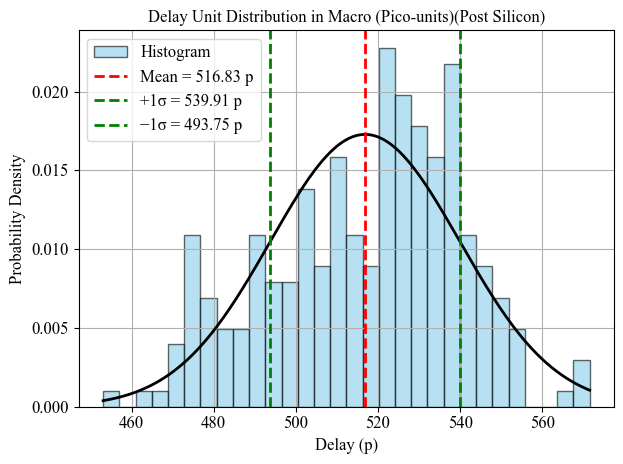

In [66]:
#780 is ideal voltage -> 
data_uncorrected = arr_diff[6].transpose()
data = arr_diff[6].flatten()
# Compute mean and std (in base units)
mean = np.mean(data)
mean_del = mean
print(mean)
std = np.std(data)
std_del = std
# Convert to pico-units
data_pico = data * 1e12
mean_pico = mean * 1e12
std_pico = std * 1e12
data_del = data_pico

# Plot histogram
count, bins, _ = plt.hist(data_pico, bins=30, density=True, alpha=0.6,
                          color='skyblue', edgecolor='black', label='Histogram')

# Overlay Gaussian curve
x = np.linspace(min(bins), max(bins), 500)
gaussian = norm.pdf(x, mean_pico, std_pico)
plt.plot(x, gaussian, color='black', linewidth=2)

# Plot mean line
plt.axvline(mean_pico, color='red', linestyle='--', linewidth=2, label=f'Mean = {mean_pico:.2f} p')

# Plot ±1σ lines
plt.axvline(mean_pico + std_pico, color='green', linestyle='--', linewidth=2,
            label=f'+1σ = {mean_pico + std_pico:.2f} p')
plt.axvline(mean_pico - std_pico, color='green', linestyle='--', linewidth=2,
            label=f'−1σ = {mean_pico - std_pico:.2f} p')

# Final touches
plt.title("Delay Unit Distribution in Macro (Pico-units)(Post Silicon)")
plt.xlabel("Delay (p)")
plt.ylabel("Probability Density")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [67]:
#Compute error from mean at each voltage level

corrected_delay = np.zeros((delaylines),dtype=np.float32)
corrected_voltage = np.zeros((delaylines),dtype=np.float32)
for dl in range(delaylines):
    min_error = 10
    for vol in range(voltages):
        delay = arr_diff[vol,dl]
        error = abs(delay-mean_del)
        if error < min_error:
            min_error = error
            corrected_delay[dl] = delay
            corrected_voltage[dl] = vol
            

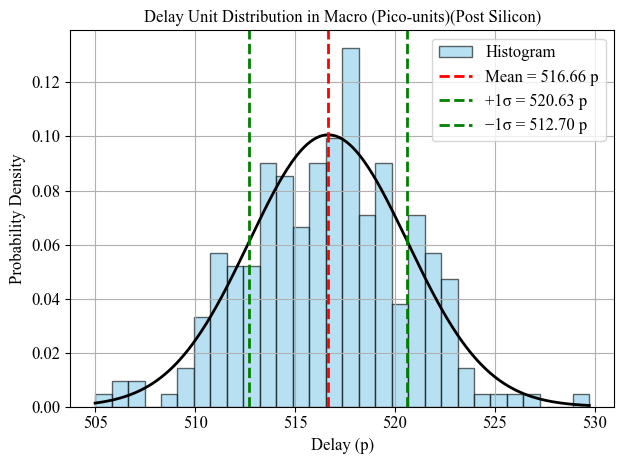

In [68]:
#780 is ideal voltage -> 
data_best_corrected = corrected_delay
data = corrected_delay.flatten()
# Compute mean and std (in base units)
mean = np.mean(data)
std = np.std(data)
mean_corrected = mean
std_corrcted = std
# Convert to pico-units
data_pico = data * 1e12
mean_pico = mean * 1e12
std_pico = std * 1e12
data_corrected = data_pico
# Plot histogram
count, bins, _ = plt.hist(data_pico, bins=30, density=True, alpha=0.6,
                          color='skyblue', edgecolor='black', label='Histogram')

# Overlay Gaussian curve
x = np.linspace(min(bins), max(bins), 500)
gaussian = norm.pdf(x, mean_pico, std_pico)
plt.plot(x, gaussian, color='black', linewidth=2)

# Plot mean line
plt.axvline(mean_pico, color='red', linestyle='--', linewidth=2, label=f'Mean = {mean_pico:.2f} p')

# Plot ±1σ lines
plt.axvline(mean_pico + std_pico, color='green', linestyle='--', linewidth=2,
            label=f'+1σ = {mean_pico + std_pico:.2f} p')
plt.axvline(mean_pico - std_pico, color='green', linestyle='--', linewidth=2,
            label=f'−1σ = {mean_pico - std_pico:.2f} p')

# Final touches
plt.title("Delay Unit Distribution in Macro (Pico-units)(Post Silicon)")
plt.xlabel("Delay (p)")
plt.ylabel("Probability Density")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

(array([ 7.,  5., 10., 20., 35., 47., 38., 37., 25., 32.]),
 array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.]),
 <BarContainer object of 10 artists>)

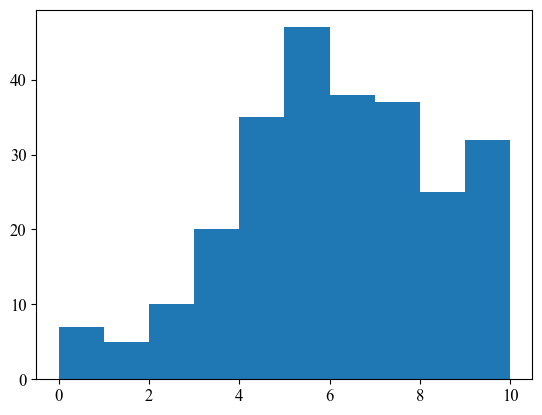

In [69]:
plt.hist(corrected_voltage.flatten())

In [70]:

corrected_delay = np.zeros((delaylines),dtype=np.float32)
corrected_voltage = np.zeros((delaylines),dtype=np.float32)
VBN_VOLTAGES = [5,6,7,8]
VBP_VOLTAGES = [2,4,6,8]
for dl in range(delaylines):
    min_error = 10
    for vol in [5,6,7,8] if VBN_FLAG else [2,4,6,8] : #[5,6,7,8] [2,4,6,8]
        delay = arr_diff[vol,dl]
        error = abs(delay-mean_del)
        if error < min_error:
            min_error = error
            corrected_delay[dl] = delay
            corrected_voltage[dl] = vol
'''
if VBN_FLAG:
    np.save("d:\Chip2025\Chip2025_Testing\Python_Notebook\Tests\Data\OSC_Calibration\VBN_CALIB_VOLTAGES.npy",corrected_voltage)
else:
   np.save("d:\Chip2025\Chip2025_Testing\Python_Notebook\Tests\Data\OSC_Calibration\VBP_CALIB_VOLTAGES.npy",corrected_voltage)
'''

'\nif VBN_FLAG:\n    np.save("d:\\Chip2025\\Chip2025_Testing\\Python_Notebook\\Tests\\Data\\OSC_Calibration\\VBN_CALIB_VOLTAGES.npy",corrected_voltage)\nelse:\n   np.save("d:\\Chip2025\\Chip2025_Testing\\Python_Notebook\\Tests\\Data\\OSC_Calibration\\VBP_CALIB_VOLTAGES.npy",corrected_voltage)\n'

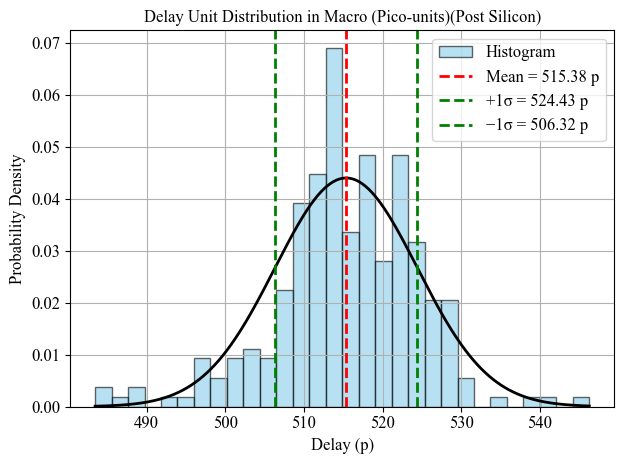

In [71]:
#780 is ideal voltage -> 
data_possible_corrected = corrected_delay
data = corrected_delay.flatten()
# Compute mean and std (in base units)
mean = np.mean(data)
std = np.std(data)
mean_poss = mean
std_poss = std
# Convert to pico-units
data_pico = data * 1e12
mean_pico = mean * 1e12
std_pico = std * 1e12
data_poss = data_pico
# Plot histogram
count, bins, _ = plt.hist(data_pico, bins=30, density=True, alpha=0.6,
                          color='skyblue', edgecolor='black', label='Histogram')

# Overlay Gaussian curve
x = np.linspace(min(bins), max(bins), 500)
gaussian = norm.pdf(x, mean_pico, std_pico)
plt.plot(x, gaussian, color='black', linewidth=2)

# Plot mean line
plt.axvline(mean_pico, color='red', linestyle='--', linewidth=2, label=f'Mean = {mean_pico:.2f} p')

# Plot ±1σ lines
plt.axvline(mean_pico + std_pico, color='green', linestyle='--', linewidth=2,
            label=f'+1σ = {mean_pico + std_pico:.2f} p')
plt.axvline(mean_pico - std_pico, color='green', linestyle='--', linewidth=2,
            label=f'−1σ = {mean_pico - std_pico:.2f} p')

# Final touches
plt.title("Delay Unit Distribution in Macro (Pico-units)(Post Silicon)")
plt.xlabel("Delay (p)")
plt.ylabel("Probability Density")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [72]:
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams['font.family'] = 'Times New Roman'   # or 'Times New Roman', 'DejaVu Sans', etc.
mpl.rcParams['font.size'] = 12

# Axis-specific defaults
mpl.rcParams['axes.titlesize'] = 12
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12
mpl.rcParams['legend.fontsize'] = 12

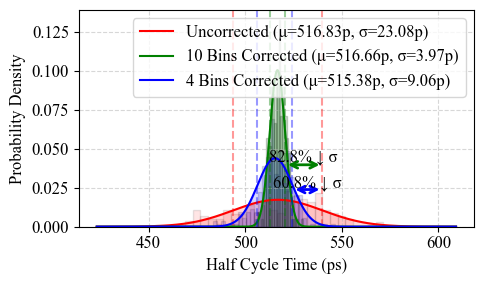

In [73]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Replace these with your actual values
# mean_del, mean_corrected, mean_poss = 120e-12, 118e-12, 119e-12
# std_del, std_corrcted, std_poss = 10e-12, 4e-12, 6e-12

labels = ['Uncorrected', '10 Bins Corrected', '4 Bins Corrected']
means_pico = [mean_del, mean_corrected, mean_poss] 
stds_pico = [std_del, std_corrcted, std_poss]

means = np.array(means_pico) * 1e12  # convert to pico
stds = np.array(stds_pico) * 1e12
x = np.linspace(min(means) - 4 * max(stds), max(means) + 4 * max(stds), 1000)

# Define new colors in requested order: red, green, blue
colors = ['red', 'green', 'blue']
perc_reduction = [(1 - s / stds[0]) * 100 for s in stds[1:]]

plt.figure(figsize=(5, 3))

count, bins, _ = plt.hist(data_del, bins=30, density=True, alpha=0.1,color='red', edgecolor='black')
count, bins, _ = plt.hist(data_poss, bins=30, density=True, alpha=0.15,color='blue', edgecolor='black')
count, bins, _ = plt.hist(data_corrected, bins=30, density=True, alpha=0.2,color='green', edgecolor='black')

for i, (mean, std, label, color) in enumerate(zip(means, stds, labels, colors)):
    pdf = norm.pdf(x, mean, std)
    plt.plot(x, pdf, label=f'{label} (μ={mean:.2f}p, σ={std:.2f}p)', color=color)
    plt.fill_between(x, pdf, alpha=0.15, color=color)

    # Draw ±1σ dashed lines
    plt.axvline(mean - std, color=color, linestyle='--', alpha=0.4)
    plt.axvline(mean + std, color=color, linestyle='--', alpha=0.4)

# Vertical base height for arrows (adjusted higher)
y_base = 2.3 * norm.pdf(means[0], means[0], stds[0])
y_base2 = y_base * 0.6

# Arrow: No Correction to Best Correction
plt.annotate(
    '', 
    xy=(means[0] + stds[0], y_base), 
    xytext=(means[1] + stds[1], y_base),
    arrowprops=dict(arrowstyle='<->', color='green', lw=2)
)
plt.text(
    (means[0] + stds[0] + means[1] + stds[1]) / 2, 
    y_base * 1.05, 
    f'{perc_reduction[0]:.1f}% ↓ σ', 
    ha='center', color='black', fontsize=12
)

# Arrow: No Correction to Possible Correction
plt.annotate(
    '', 
    xy=(means[0] + stds[0], y_base2), 
    xytext=(means[2] + stds[2], y_base2),
    arrowprops=dict(arrowstyle='<->', color='blue', lw=2)
)
plt.text(
    (means[0] + stds[0] + means[2] + stds[2]) / 2, 
    y_base2 * 1.05, 
    f'{perc_reduction[1]:.1f}% ↓ σ', 
    ha='center', color='black', fontsize=12
)

# Final plot formatting
#plt.title('Oscillator Rising Edge Correction (Post Silicon)')
plt.xlabel('Half Cycle Time (ps)')
plt.ylabel('Probability Density')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig("D:\ISSCC_26\Graphs\OscRise_Correction.jpg",dpi=300, bbox_inches="tight", transparent=True)
plt.show()
